In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def preprocess_cifar(dataset_name='CIFAR100', batch_size=64, val_split=0.2):
    """
    Preprocess CIFAR-10 or CIFAR-100 dataset dynamically.
    :param dataset_name: 'CIFAR10' or 'CIFAR100'
    :param batch_size: Batch size for DataLoader
    :param val_split: Fraction of training data to use for validation
    :return: train_loader, val_loader, test_loader, num_classes
    """
    assert dataset_name in ['CIFAR10', 'CIFAR100'], "Invalid dataset name. Choose CIFAR10 or CIFAR100."

    DatasetClass = getattr(datasets, dataset_name)

    # Load dataset without transformations to calculate mean & std
    dataset = DatasetClass(root='./data', train=True, download=True, transform=transforms.ToTensor())
    data_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

    # Compute mean and std for normalization
    mean = torch.zeros(3)
    std = torch.zeros(3)
    for images, _ in data_loader:
        for i in range(3):
            mean[i] = images[:, i, :, :].mean()
            std[i] = images[:, i, :, :].std()

    print(f"Mean: {mean}")
    print(f"Standard Deviation: {std}")

    # Define transformations
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # Load train & test datasets with transformations
    train_dataset = DatasetClass(root='./data', train=True, download=True, transform=transform_train)
    test_dataset = DatasetClass(root='./data', train=False, download=True, transform=transform_test)

    num_classes = len(train_dataset.classes)

    # One-hot encode labels
    def one_hot_encode(labels, num_classes):
        return F.one_hot(torch.tensor(labels), num_classes=num_classes)

    train_dataset.targets = one_hot_encode(train_dataset.targets, num_classes)
    test_dataset.targets = one_hot_encode(test_dataset.targets, num_classes)

    # Split training data into train & validation
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Training dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")
    print(f"Testing dataset size: {len(test_dataset)}")
    print(f"Number of classes: {num_classes}")

    return train_loader, val_loader, test_loader, num_classes


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, activation=nn.ReLU, use_batchnorm=True):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
        self.activation = activation(inplace=True)

        # If input and output channels are different, use a 1x1 conv to match dimensions
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)  # Residual connection
        out = self.activation(out)
        return out

class CNNModel(nn.Module):
    def __init__(self, num_classes=100, activation=nn.ReLU, use_batchnorm=True, dropout_rate=0.5):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()

        self.res_block1 = ResidualBlock(64, 128, activation=activation, use_batchnorm=use_batchnorm)
        self.res_block2 = ResidualBlock(128, 256, activation=activation, use_batchnorm=use_batchnorm)
        self.res_block3 = ResidualBlock(256, 512, activation=activation, use_batchnorm=use_batchnorm)
        self.res_block4 = ResidualBlock(512, 512, activation=activation, use_batchnorm=use_batchnorm)

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x) if isinstance(self.bn1, nn.Identity) else x
        x = self.res_block1(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = self.res_block2(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = self.res_block3(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = self.res_block4(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Example Usage
# model = CNNModel(num_classes=100, activation=nn.LeakyReLU, use_batchnorm=True, dropout_rate=0.3)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, num_epochs=25, lr=0.001, optimizer_type='Adam', use_scheduler=True, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer type. Choose 'Adam' or 'SGD'.")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True) if use_scheduler else None

    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = torch.argmax(targets, dim=1)  # Convert one-hot to class index

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        correct, total = 0, 0
        val_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                targets = torch.argmax(targets, dim=1)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if scheduler:
            scheduler.step(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%")

    # Plotting training progress
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return model


In [4]:
def run_experiments(
    dataset_name='CIFAR10',
    activation_list=[nn.ReLU, nn.LeakyReLU],
    optimizer_list=['Adam', 'SGD'],
    dropout_rates=[0.3, 0.5],
    learning_rates=[0.001, 0.01],
    num_epochs=20
):

    results = []

    train_loader, val_loader, test_loader, num_classes = preprocess_cifar(dataset_name=dataset_name)

    for activation in activation_list:
        for optimizer_type in optimizer_list:
            for dropout_rate in dropout_rates:
                for lr in learning_rates:
                    print(f"\nRunning: {activation.__name__}, {optimizer_type}, Dropout={dropout_rate}, LR={lr}")

                    model = CNNModel(
                        num_classes=num_classes,
                        activation=activation,
                        use_batchnorm=True,
                        dropout_rate=dropout_rate
                    )

                    trained_model = train_model(
                        model,
                        train_loader,
                        val_loader,
                        num_epochs=num_epochs,
                        lr=lr,
                        optimizer_type=optimizer_type,
                        use_scheduler=True,
                        device=device
                    )

                    # Placeholder: You can improve this by evaluating on test set
                    # Here we only use last validation accuracy
                    val_acc = train_model.val_accuracies[-1] if hasattr(train_model, 'val_accuracies') else None

                    results.append({
                        'activation': activation.__name__,
                        'optimizer': optimizer_type,
                        'dropout_rate': dropout_rate,
                        'learning_rate': lr,
                        'val_accuracy': val_acc
                    })

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by='val_accuracy', ascending=False)
    print("\nTop Results:")
    print(df_results.head())
    return df_results


100%|██████████| 169M/169M [00:12<00:00, 13.1MB/s]


Mean: tensor([0.5071, 0.4865, 0.4409])
Standard Deviation: tensor([0.2673, 0.2564, 0.2762])
Training dataset size: 40000
Validation dataset size: 10000
Testing dataset size: 10000
Number of classes: 100

Running: ReLU, Adam, Dropout=0.3, LR=0.001


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/20] - Train Loss: 3.8652 - Val Loss: 3.2297 - Val Acc: 20.14%
Epoch [2/20] - Train Loss: 2.9978 - Val Loss: 2.8138 - Val Acc: 27.91%
Epoch [3/20] - Train Loss: 2.5344 - Val Loss: 2.3590 - Val Acc: 37.31%
Epoch [4/20] - Train Loss: 2.2306 - Val Loss: 2.2276 - Val Acc: 40.76%
Epoch [5/20] - Train Loss: 2.0051 - Val Loss: 2.1498 - Val Acc: 42.87%
Epoch [6/20] - Train Loss: 1.8079 - Val Loss: 1.8405 - Val Acc: 50.05%
Epoch [7/20] - Train Loss: 1.6570 - Val Loss: 1.7824 - Val Acc: 51.01%
Epoch [8/20] - Train Loss: 1.5151 - Val Loss: 1.6854 - Val Acc: 53.10%
Epoch [9/20] - Train Loss: 1.3992 - Val Loss: 1.6244 - Val Acc: 55.28%
Epoch [10/20] - Train Loss: 1.2899 - Val Loss: 1.5225 - Val Acc: 57.68%
Epoch [11/20] - Train Loss: 1.1894 - Val Loss: 1.4642 - Val Acc: 59.51%
Epoch [12/20] - Train Loss: 1.1031 - Val Loss: 1.4852 - Val Acc: 59.54%
Epoch [13/20] - Train Loss: 1.0188 - Val Loss: 1.4429 - Val Acc: 60.54%
Epoch [14/20] - Train Loss: 0.9329 - Val Loss: 1.4323 - Val Acc: 61.39%
E

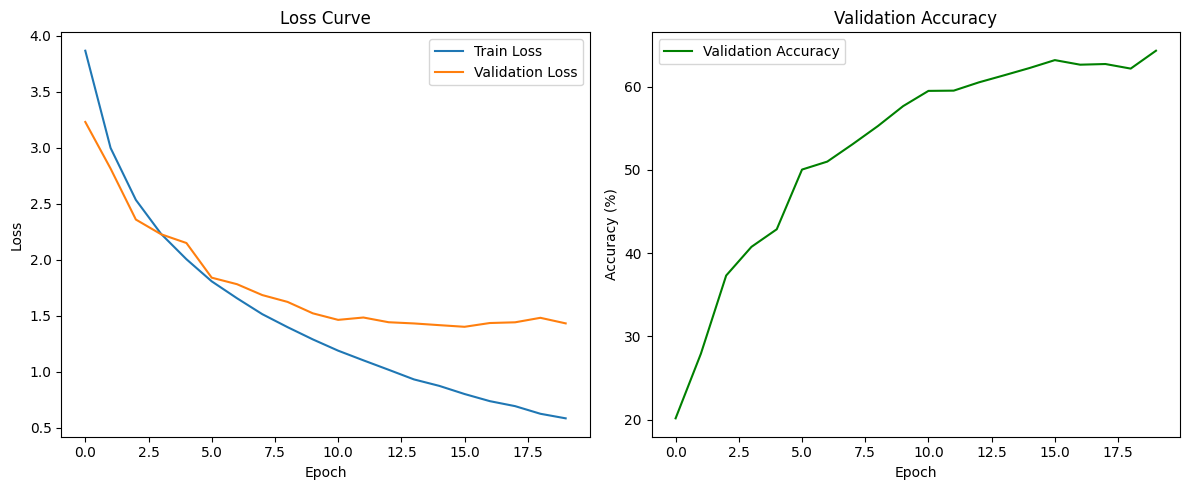


Running: ReLU, Adam, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 4.3066 - Val Loss: 3.8837 - Val Acc: 9.37%
Epoch [2/20] - Train Loss: 3.6963 - Val Loss: 3.4092 - Val Acc: 17.43%
Epoch [3/20] - Train Loss: 3.1944 - Val Loss: 2.9378 - Val Acc: 26.58%
Epoch [4/20] - Train Loss: 2.7114 - Val Loss: 2.5886 - Val Acc: 32.85%
Epoch [5/20] - Train Loss: 2.3852 - Val Loss: 2.3760 - Val Acc: 38.22%
Epoch [6/20] - Train Loss: 2.1495 - Val Loss: 2.1219 - Val Acc: 43.44%
Epoch [7/20] - Train Loss: 1.9639 - Val Loss: 1.9400 - Val Acc: 47.23%
Epoch [8/20] - Train Loss: 1.8104 - Val Loss: 1.8421 - Val Acc: 50.43%
Epoch [9/20] - Train Loss: 1.6786 - Val Loss: 1.8651 - Val Acc: 50.14%
Epoch [10/20] - Train Loss: 1.5810 - Val Loss: 1.6789 - Val Acc: 53.86%
Epoch [11/20] - Train Loss: 1.4731 - Val Loss: 1.6453 - Val Acc: 55.37%
Epoch [12/20] - Train Loss: 1.3951 - Val Loss: 1.6528 - Val Acc: 55.81%
Epoch [13/20] - Train Loss: 1.3141 - Val Loss: 1.6160 - Val Acc: 56.66%
Epoch [14/20] - Train Loss: 1.2

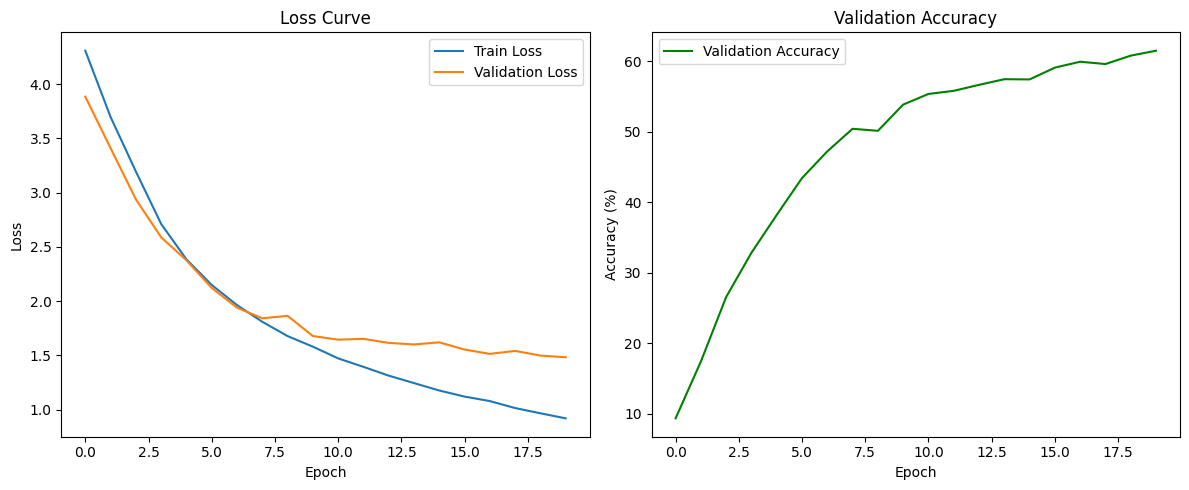


Running: ReLU, Adam, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 3.9991 - Val Loss: 3.7844 - Val Acc: 11.95%
Epoch [2/20] - Train Loss: 3.1923 - Val Loss: 3.1991 - Val Acc: 21.57%
Epoch [3/20] - Train Loss: 2.7318 - Val Loss: 2.6566 - Val Acc: 31.78%
Epoch [4/20] - Train Loss: 2.4139 - Val Loss: 2.3021 - Val Acc: 38.95%
Epoch [5/20] - Train Loss: 2.1597 - Val Loss: 2.1306 - Val Acc: 42.43%
Epoch [6/20] - Train Loss: 1.9662 - Val Loss: 1.9008 - Val Acc: 47.68%
Epoch [7/20] - Train Loss: 1.7995 - Val Loss: 1.8212 - Val Acc: 49.98%
Epoch [8/20] - Train Loss: 1.6535 - Val Loss: 1.7039 - Val Acc: 52.45%
Epoch [9/20] - Train Loss: 1.5476 - Val Loss: 1.6667 - Val Acc: 53.92%
Epoch [10/20] - Train Loss: 1.4292 - Val Loss: 1.6138 - Val Acc: 55.69%
Epoch [11/20] - Train Loss: 1.3457 - Val Loss: 1.4845 - Val Acc: 58.53%
Epoch [12/20] - Train Loss: 1.2468 - Val Loss: 1.4921 - Val Acc: 59.27%
Epoch [13/20] - Train Loss: 1.1666 - Val Loss: 1.4232 - Val Acc: 60.30%
Epoch [14/20] - Train Loss: 1

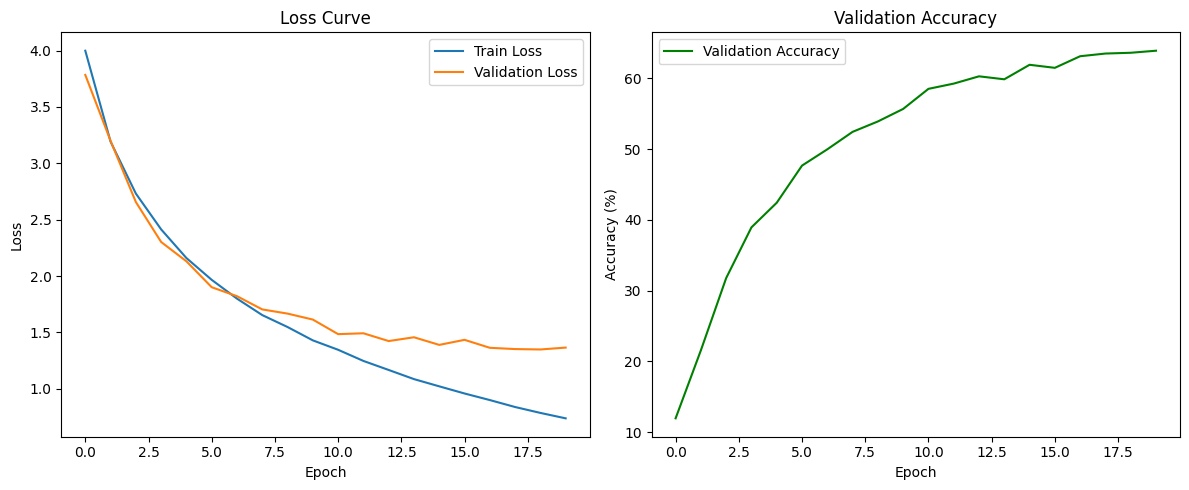


Running: ReLU, Adam, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 4.3662 - Val Loss: 3.9462 - Val Acc: 8.28%
Epoch [2/20] - Train Loss: 3.7919 - Val Loss: 3.4874 - Val Acc: 16.00%
Epoch [3/20] - Train Loss: 3.3959 - Val Loss: 3.0508 - Val Acc: 23.28%
Epoch [4/20] - Train Loss: 2.9503 - Val Loss: 3.3922 - Val Acc: 20.82%
Epoch [5/20] - Train Loss: 2.6192 - Val Loss: 2.4085 - Val Acc: 36.25%
Epoch [6/20] - Train Loss: 2.3665 - Val Loss: 2.1563 - Val Acc: 42.55%
Epoch [7/20] - Train Loss: 2.1720 - Val Loss: 2.0307 - Val Acc: 44.59%
Epoch [8/20] - Train Loss: 2.0252 - Val Loss: 1.9590 - Val Acc: 46.91%
Epoch [9/20] - Train Loss: 1.9027 - Val Loss: 1.8422 - Val Acc: 50.22%
Epoch [10/20] - Train Loss: 1.7878 - Val Loss: 1.7858 - Val Acc: 51.16%
Epoch [11/20] - Train Loss: 1.6856 - Val Loss: 1.7438 - Val Acc: 52.13%
Epoch [12/20] - Train Loss: 1.5959 - Val Loss: 1.6739 - Val Acc: 54.01%
Epoch [13/20] - Train Loss: 1.5324 - Val Loss: 1.6658 - Val Acc: 54.59%
Epoch [14/20] - Train Loss: 1.4

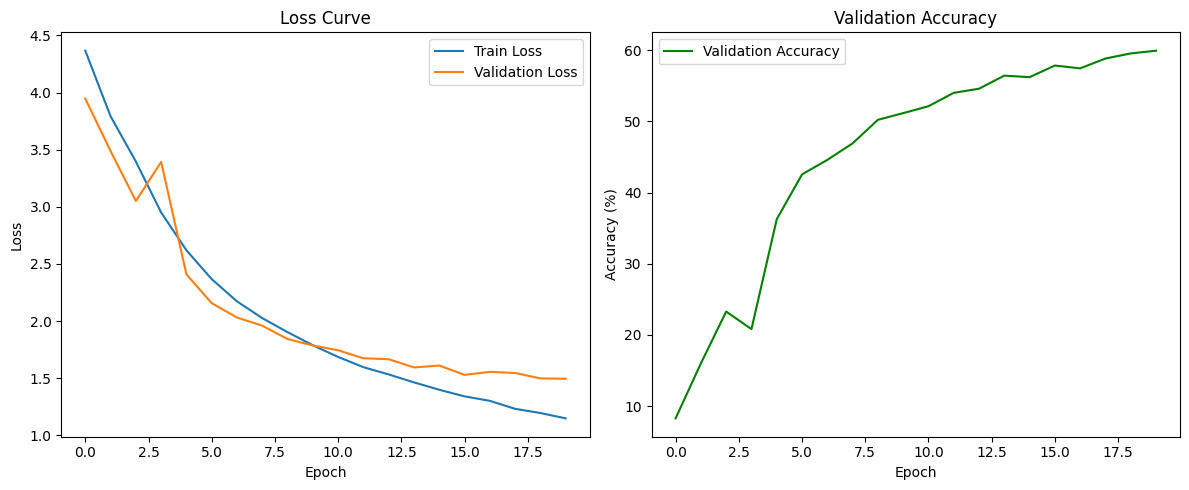


Running: ReLU, SGD, Dropout=0.3, LR=0.001
Epoch [1/20] - Train Loss: 3.9639 - Val Loss: 3.4276 - Val Acc: 17.16%
Epoch [2/20] - Train Loss: 3.2965 - Val Loss: 2.9859 - Val Acc: 25.54%
Epoch [3/20] - Train Loss: 2.9288 - Val Loss: 2.7394 - Val Acc: 30.34%
Epoch [4/20] - Train Loss: 2.6680 - Val Loss: 2.5146 - Val Acc: 35.05%
Epoch [5/20] - Train Loss: 2.4611 - Val Loss: 2.3905 - Val Acc: 37.83%
Epoch [6/20] - Train Loss: 2.2907 - Val Loss: 2.3012 - Val Acc: 39.67%
Epoch [7/20] - Train Loss: 2.1486 - Val Loss: 2.2818 - Val Acc: 40.09%
Epoch [8/20] - Train Loss: 2.0384 - Val Loss: 2.0436 - Val Acc: 45.55%
Epoch [9/20] - Train Loss: 1.9312 - Val Loss: 2.0530 - Val Acc: 44.98%
Epoch [10/20] - Train Loss: 1.8575 - Val Loss: 1.9646 - Val Acc: 47.14%
Epoch [11/20] - Train Loss: 1.7741 - Val Loss: 1.8594 - Val Acc: 49.16%
Epoch [12/20] - Train Loss: 1.7025 - Val Loss: 1.7670 - Val Acc: 51.46%
Epoch [13/20] - Train Loss: 1.6471 - Val Loss: 1.8295 - Val Acc: 49.94%
Epoch [14/20] - Train Loss: 1.

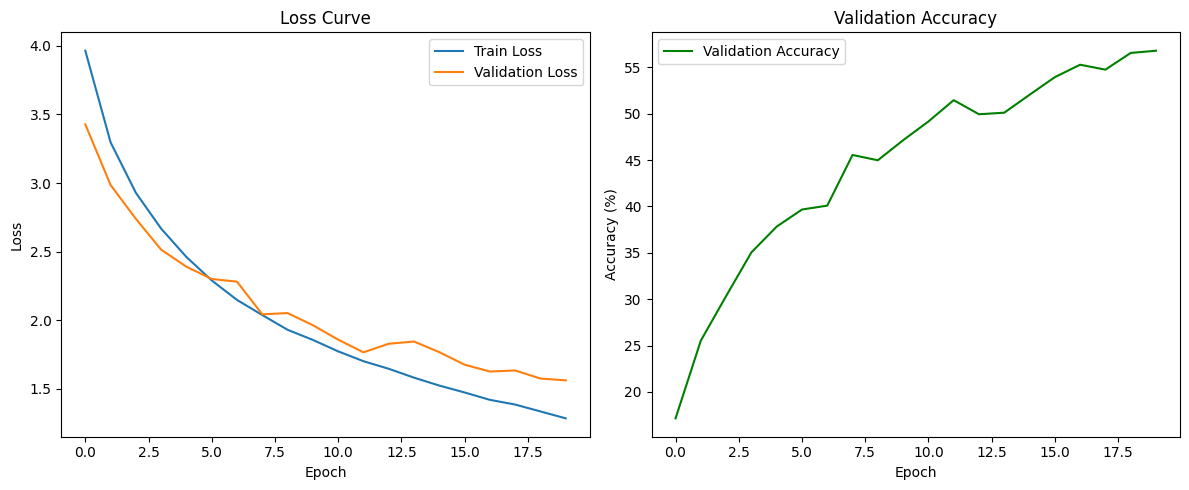


Running: ReLU, SGD, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 3.8656 - Val Loss: 3.6244 - Val Acc: 15.21%
Epoch [2/20] - Train Loss: 3.0620 - Val Loss: 2.9196 - Val Acc: 26.51%
Epoch [3/20] - Train Loss: 2.6408 - Val Loss: 2.6671 - Val Acc: 31.10%
Epoch [4/20] - Train Loss: 2.3470 - Val Loss: 2.2773 - Val Acc: 39.25%
Epoch [5/20] - Train Loss: 2.1230 - Val Loss: 2.1386 - Val Acc: 42.60%
Epoch [6/20] - Train Loss: 1.9327 - Val Loss: 1.9725 - Val Acc: 46.70%
Epoch [7/20] - Train Loss: 1.7936 - Val Loss: 1.8277 - Val Acc: 50.18%
Epoch [8/20] - Train Loss: 1.6613 - Val Loss: 1.7728 - Val Acc: 51.75%
Epoch [9/20] - Train Loss: 1.5435 - Val Loss: 1.6870 - Val Acc: 53.08%
Epoch [10/20] - Train Loss: 1.4498 - Val Loss: 1.5968 - Val Acc: 55.92%
Epoch [11/20] - Train Loss: 1.3651 - Val Loss: 1.6306 - Val Acc: 54.73%
Epoch [12/20] - Train Loss: 1.2813 - Val Loss: 1.5156 - Val Acc: 57.42%
Epoch [13/20] - Train Loss: 1.2065 - Val Loss: 1.5473 - Val Acc: 57.10%
Epoch [14/20] - Train Loss: 1.1

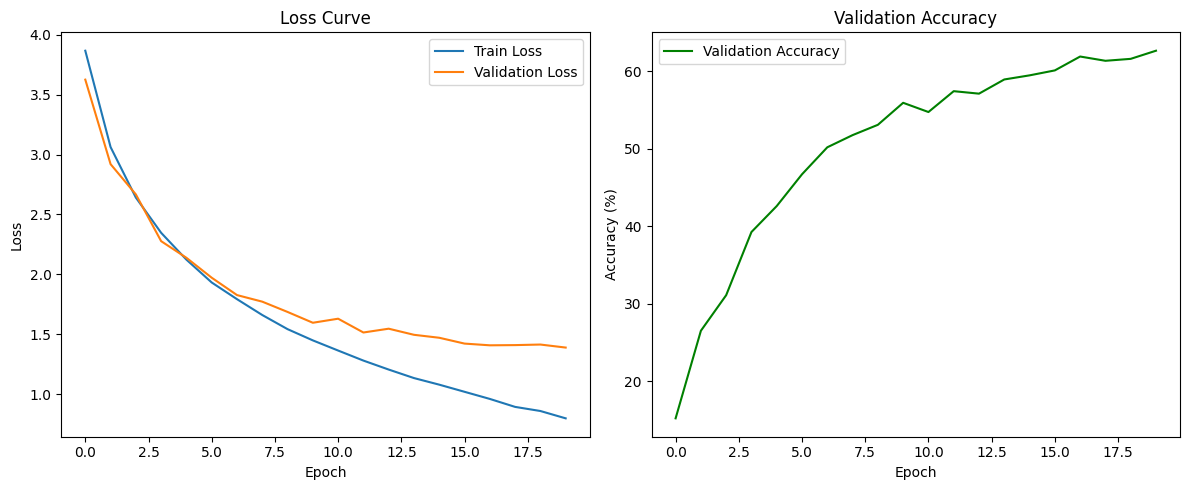


Running: ReLU, SGD, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 4.1606 - Val Loss: 3.5708 - Val Acc: 15.73%
Epoch [2/20] - Train Loss: 3.5612 - Val Loss: 3.2121 - Val Acc: 21.78%
Epoch [3/20] - Train Loss: 3.1860 - Val Loss: 2.8857 - Val Acc: 27.27%
Epoch [4/20] - Train Loss: 2.9407 - Val Loss: 2.7423 - Val Acc: 29.94%
Epoch [5/20] - Train Loss: 2.7376 - Val Loss: 2.6101 - Val Acc: 33.17%
Epoch [6/20] - Train Loss: 2.5677 - Val Loss: 2.5517 - Val Acc: 34.17%
Epoch [7/20] - Train Loss: 2.4204 - Val Loss: 2.3609 - Val Acc: 38.59%
Epoch [8/20] - Train Loss: 2.2913 - Val Loss: 2.2266 - Val Acc: 41.23%
Epoch [9/20] - Train Loss: 2.1882 - Val Loss: 2.1272 - Val Acc: 43.28%
Epoch [10/20] - Train Loss: 2.0952 - Val Loss: 2.1063 - Val Acc: 43.50%
Epoch [11/20] - Train Loss: 2.0134 - Val Loss: 1.9853 - Val Acc: 46.81%
Epoch [12/20] - Train Loss: 1.9342 - Val Loss: 1.9003 - Val Acc: 48.46%
Epoch [13/20] - Train Loss: 1.8643 - Val Loss: 1.8830 - Val Acc: 48.82%
Epoch [14/20] - Train Loss: 1.

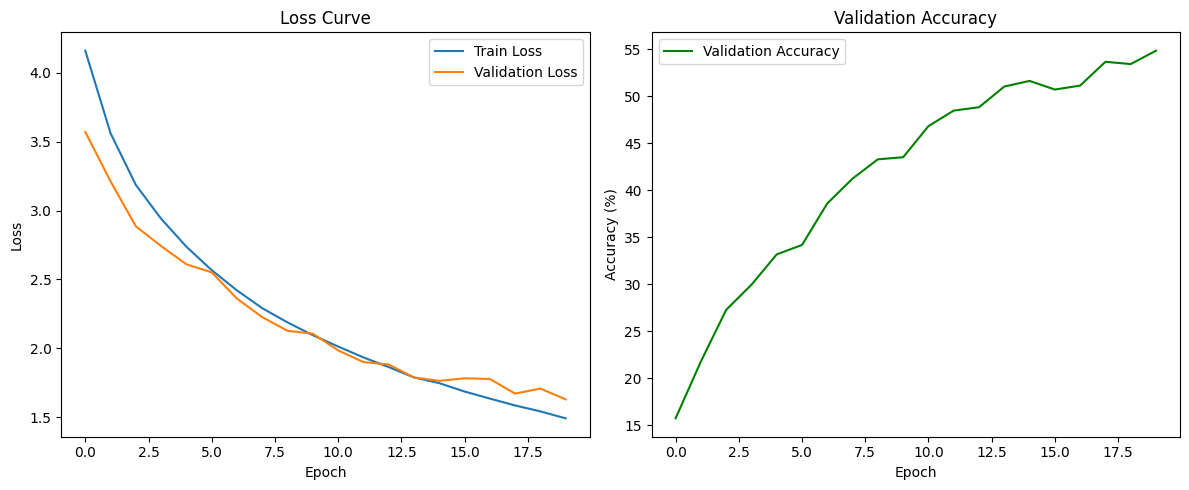


Running: ReLU, SGD, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 4.0014 - Val Loss: 3.7953 - Val Acc: 12.11%
Epoch [2/20] - Train Loss: 3.2281 - Val Loss: 2.9311 - Val Acc: 24.53%
Epoch [3/20] - Train Loss: 2.8188 - Val Loss: 2.6516 - Val Acc: 30.96%
Epoch [4/20] - Train Loss: 2.5120 - Val Loss: 2.4097 - Val Acc: 36.60%
Epoch [5/20] - Train Loss: 2.2757 - Val Loss: 2.1175 - Val Acc: 43.41%
Epoch [6/20] - Train Loss: 2.0891 - Val Loss: 2.0334 - Val Acc: 45.26%
Epoch [7/20] - Train Loss: 1.9277 - Val Loss: 2.0051 - Val Acc: 45.48%
Epoch [8/20] - Train Loss: 1.8090 - Val Loss: 1.8012 - Val Acc: 50.31%
Epoch [9/20] - Train Loss: 1.7024 - Val Loss: 1.7260 - Val Acc: 52.55%
Epoch [10/20] - Train Loss: 1.5886 - Val Loss: 1.6899 - Val Acc: 53.56%
Epoch [11/20] - Train Loss: 1.5173 - Val Loss: 1.6231 - Val Acc: 54.40%
Epoch [12/20] - Train Loss: 1.4345 - Val Loss: 1.5627 - Val Acc: 56.17%
Epoch [13/20] - Train Loss: 1.3547 - Val Loss: 1.5262 - Val Acc: 57.76%
Epoch [14/20] - Train Loss: 1.2

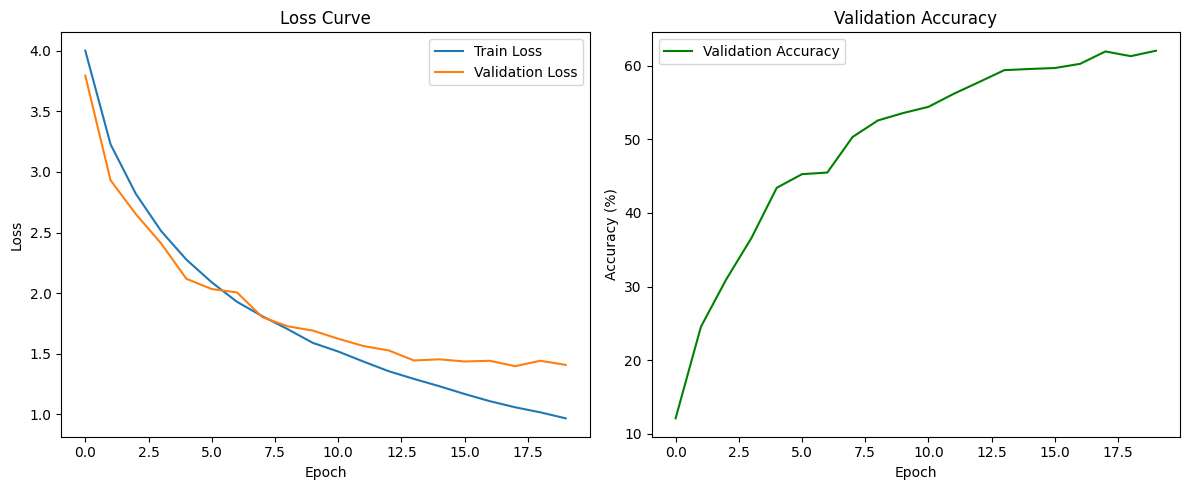


Running: LeakyReLU, Adam, Dropout=0.3, LR=0.001
Epoch [1/20] - Train Loss: 3.9136 - Val Loss: 3.3541 - Val Acc: 16.67%
Epoch [2/20] - Train Loss: 3.0490 - Val Loss: 3.0337 - Val Acc: 24.39%
Epoch [3/20] - Train Loss: 2.5730 - Val Loss: 2.4022 - Val Acc: 36.54%
Epoch [4/20] - Train Loss: 2.2559 - Val Loss: 2.1966 - Val Acc: 40.20%
Epoch [5/20] - Train Loss: 2.0125 - Val Loss: 2.0100 - Val Acc: 45.92%
Epoch [6/20] - Train Loss: 1.8180 - Val Loss: 1.9974 - Val Acc: 46.62%
Epoch [7/20] - Train Loss: 1.6564 - Val Loss: 1.8156 - Val Acc: 49.96%
Epoch [8/20] - Train Loss: 1.5216 - Val Loss: 1.6717 - Val Acc: 53.04%
Epoch [9/20] - Train Loss: 1.4051 - Val Loss: 1.5980 - Val Acc: 56.33%
Epoch [10/20] - Train Loss: 1.3017 - Val Loss: 1.5630 - Val Acc: 56.69%
Epoch [11/20] - Train Loss: 1.1976 - Val Loss: 1.5355 - Val Acc: 57.80%
Epoch [12/20] - Train Loss: 1.1142 - Val Loss: 1.4688 - Val Acc: 60.14%
Epoch [13/20] - Train Loss: 1.0408 - Val Loss: 1.4496 - Val Acc: 60.67%
Epoch [14/20] - Train Lo

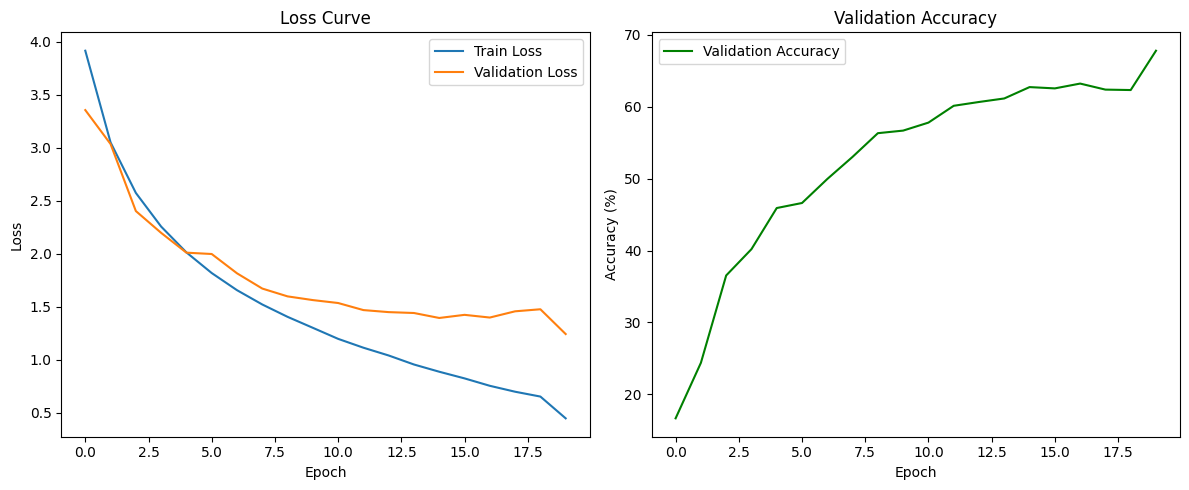


Running: LeakyReLU, Adam, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 4.2832 - Val Loss: 3.8994 - Val Acc: 8.94%
Epoch [2/20] - Train Loss: 3.6911 - Val Loss: 3.4365 - Val Acc: 16.24%
Epoch [3/20] - Train Loss: 3.2257 - Val Loss: 3.0728 - Val Acc: 23.34%
Epoch [4/20] - Train Loss: 2.7488 - Val Loss: 2.6118 - Val Acc: 32.42%
Epoch [5/20] - Train Loss: 2.4166 - Val Loss: 2.2466 - Val Acc: 40.52%
Epoch [6/20] - Train Loss: 2.1695 - Val Loss: 2.2709 - Val Acc: 40.17%
Epoch [7/20] - Train Loss: 1.9601 - Val Loss: 1.9750 - Val Acc: 46.91%
Epoch [8/20] - Train Loss: 1.8167 - Val Loss: 2.2299 - Val Acc: 43.87%
Epoch [9/20] - Train Loss: 1.6852 - Val Loss: 1.8724 - Val Acc: 49.72%
Epoch [10/20] - Train Loss: 1.5779 - Val Loss: 1.7488 - Val Acc: 52.28%
Epoch [11/20] - Train Loss: 1.4774 - Val Loss: 1.7149 - Val Acc: 54.04%
Epoch [12/20] - Train Loss: 1.3887 - Val Loss: 1.6121 - Val Acc: 56.33%
Epoch [13/20] - Train Loss: 1.3101 - Val Loss: 1.6296 - Val Acc: 56.17%
Epoch [14/20] - Train Loss

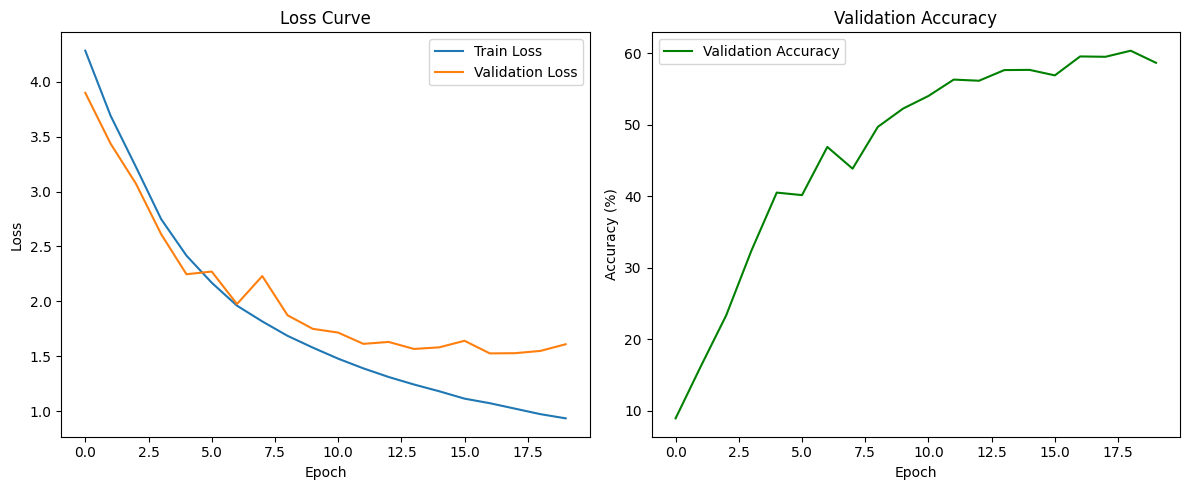


Running: LeakyReLU, Adam, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 3.9800 - Val Loss: 3.5672 - Val Acc: 14.14%
Epoch [2/20] - Train Loss: 3.1771 - Val Loss: 2.9834 - Val Acc: 24.55%
Epoch [3/20] - Train Loss: 2.7013 - Val Loss: 2.5839 - Val Acc: 32.59%
Epoch [4/20] - Train Loss: 2.3963 - Val Loss: 2.2948 - Val Acc: 38.46%
Epoch [5/20] - Train Loss: 2.1621 - Val Loss: 2.0555 - Val Acc: 45.33%
Epoch [6/20] - Train Loss: 1.9596 - Val Loss: 1.9910 - Val Acc: 46.21%
Epoch [7/20] - Train Loss: 1.7977 - Val Loss: 1.8819 - Val Acc: 48.59%
Epoch [8/20] - Train Loss: 1.6547 - Val Loss: 1.6464 - Val Acc: 54.42%
Epoch [9/20] - Train Loss: 1.5268 - Val Loss: 1.6150 - Val Acc: 54.97%
Epoch [10/20] - Train Loss: 1.4264 - Val Loss: 1.5480 - Val Acc: 56.85%
Epoch [11/20] - Train Loss: 1.3294 - Val Loss: 1.5298 - Val Acc: 57.77%
Epoch [12/20] - Train Loss: 1.2450 - Val Loss: 1.4633 - Val Acc: 59.45%
Epoch [13/20] - Train Loss: 1.1578 - Val Loss: 1.4715 - Val Acc: 59.74%
Epoch [14/20] - Train Lo

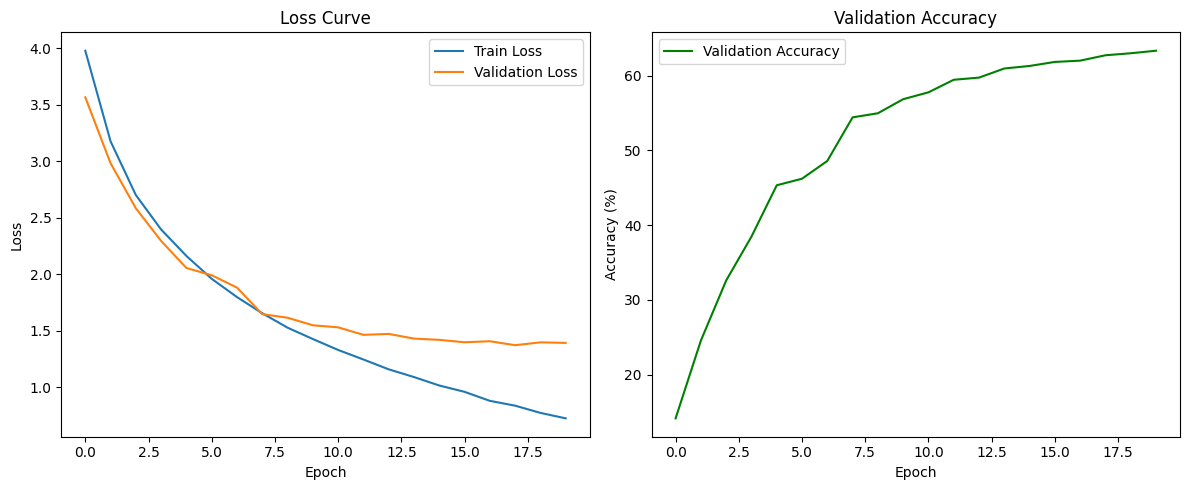


Running: LeakyReLU, Adam, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 4.3451 - Val Loss: 3.9856 - Val Acc: 8.09%
Epoch [2/20] - Train Loss: 3.7898 - Val Loss: 3.4966 - Val Acc: 15.09%
Epoch [3/20] - Train Loss: 3.3595 - Val Loss: 2.9932 - Val Acc: 24.81%
Epoch [4/20] - Train Loss: 2.9111 - Val Loss: 2.6879 - Val Acc: 30.28%
Epoch [5/20] - Train Loss: 2.5918 - Val Loss: 2.4383 - Val Acc: 36.31%
Epoch [6/20] - Train Loss: 2.3542 - Val Loss: 2.2556 - Val Acc: 40.77%
Epoch [7/20] - Train Loss: 2.1594 - Val Loss: 2.0889 - Val Acc: 44.32%
Epoch [8/20] - Train Loss: 1.9961 - Val Loss: 1.9844 - Val Acc: 46.79%
Epoch [9/20] - Train Loss: 1.8729 - Val Loss: 1.8580 - Val Acc: 49.60%
Epoch [10/20] - Train Loss: 1.7607 - Val Loss: 1.7812 - Val Acc: 52.00%
Epoch [11/20] - Train Loss: 1.6696 - Val Loss: 1.7410 - Val Acc: 52.63%
Epoch [12/20] - Train Loss: 1.5867 - Val Loss: 1.6460 - Val Acc: 54.79%
Epoch [13/20] - Train Loss: 1.5076 - Val Loss: 1.6580 - Val Acc: 54.84%
Epoch [14/20] - Train Loss

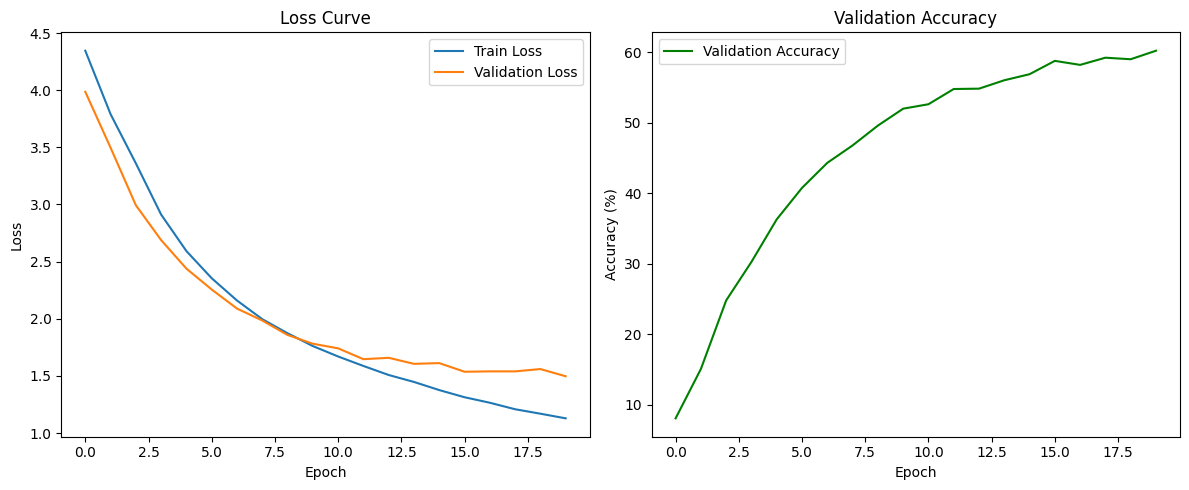


Running: LeakyReLU, SGD, Dropout=0.3, LR=0.001
Epoch [1/20] - Train Loss: 3.9791 - Val Loss: 3.4201 - Val Acc: 17.32%
Epoch [2/20] - Train Loss: 3.3055 - Val Loss: 3.1047 - Val Acc: 22.61%
Epoch [3/20] - Train Loss: 2.9488 - Val Loss: 2.8508 - Val Acc: 28.32%
Epoch [4/20] - Train Loss: 2.6832 - Val Loss: 2.5308 - Val Acc: 34.64%
Epoch [5/20] - Train Loss: 2.4771 - Val Loss: 2.4159 - Val Acc: 36.96%
Epoch [6/20] - Train Loss: 2.3044 - Val Loss: 2.2767 - Val Acc: 40.00%
Epoch [7/20] - Train Loss: 2.1625 - Val Loss: 2.1886 - Val Acc: 41.70%
Epoch [8/20] - Train Loss: 2.0527 - Val Loss: 2.0277 - Val Acc: 45.33%
Epoch [9/20] - Train Loss: 1.9457 - Val Loss: 1.9579 - Val Acc: 47.48%
Epoch [10/20] - Train Loss: 1.8624 - Val Loss: 1.9252 - Val Acc: 48.42%
Epoch [11/20] - Train Loss: 1.7780 - Val Loss: 1.8736 - Val Acc: 49.60%
Epoch [12/20] - Train Loss: 1.7086 - Val Loss: 1.8365 - Val Acc: 50.00%
Epoch [13/20] - Train Loss: 1.6537 - Val Loss: 1.8187 - Val Acc: 50.58%
Epoch [14/20] - Train Los

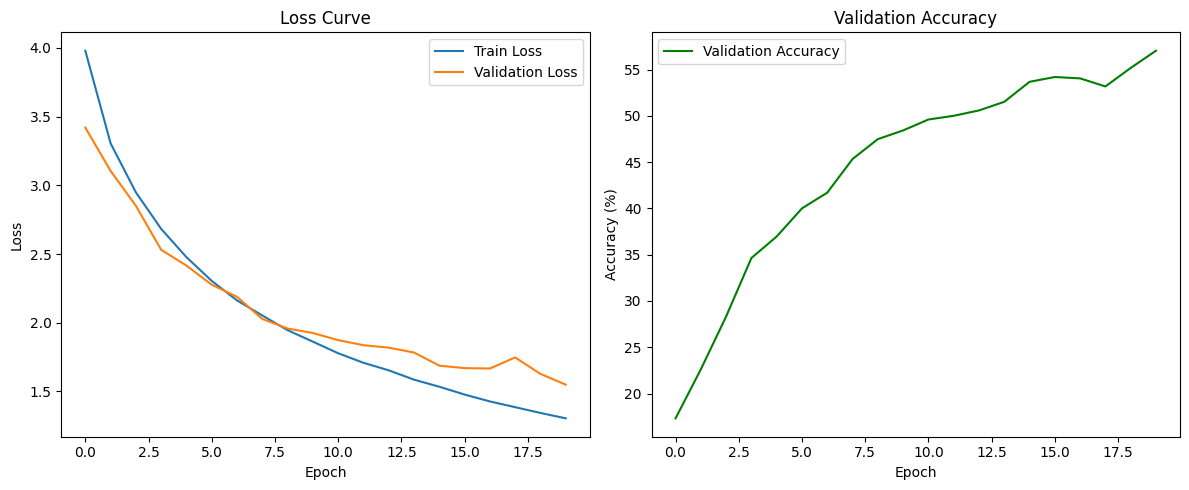


Running: LeakyReLU, SGD, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 3.8433 - Val Loss: 3.3035 - Val Acc: 18.58%
Epoch [2/20] - Train Loss: 3.0109 - Val Loss: 2.9228 - Val Acc: 24.98%
Epoch [3/20] - Train Loss: 2.5863 - Val Loss: 2.5710 - Val Acc: 33.11%
Epoch [4/20] - Train Loss: 2.2902 - Val Loss: 2.2383 - Val Acc: 40.00%
Epoch [5/20] - Train Loss: 2.0673 - Val Loss: 2.0623 - Val Acc: 44.42%
Epoch [6/20] - Train Loss: 1.8924 - Val Loss: 1.8791 - Val Acc: 48.93%
Epoch [7/20] - Train Loss: 1.7375 - Val Loss: 1.8005 - Val Acc: 49.75%
Epoch [8/20] - Train Loss: 1.6184 - Val Loss: 1.7420 - Val Acc: 51.84%
Epoch [9/20] - Train Loss: 1.5093 - Val Loss: 1.6676 - Val Acc: 54.02%
Epoch [10/20] - Train Loss: 1.4144 - Val Loss: 1.6329 - Val Acc: 55.27%
Epoch [11/20] - Train Loss: 1.3389 - Val Loss: 1.5427 - Val Acc: 57.20%
Epoch [12/20] - Train Loss: 1.2632 - Val Loss: 1.5144 - Val Acc: 58.01%
Epoch [13/20] - Train Loss: 1.1793 - Val Loss: 1.5444 - Val Acc: 57.78%
Epoch [14/20] - Train Loss

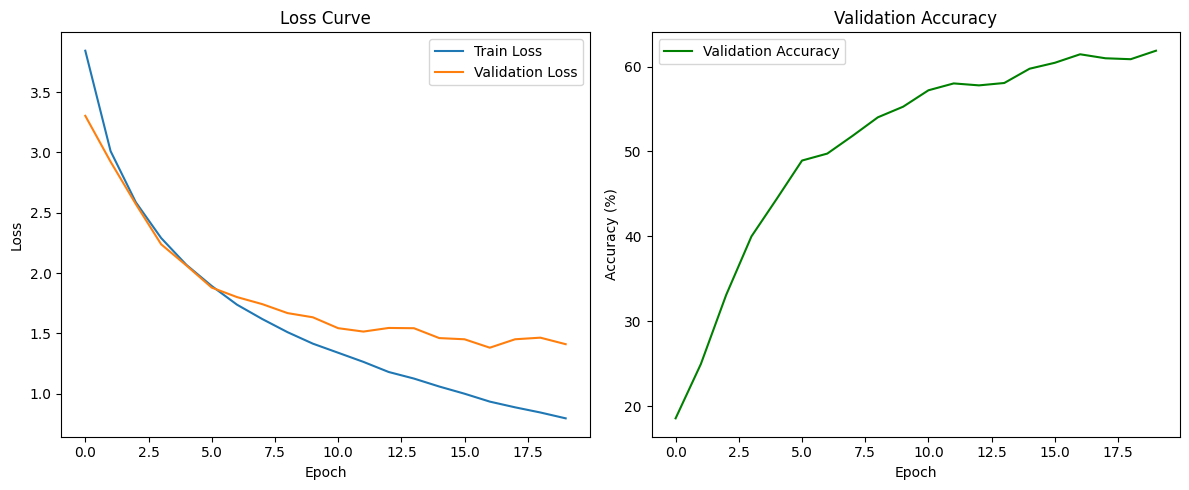


Running: LeakyReLU, SGD, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 4.1522 - Val Loss: 3.5659 - Val Acc: 15.86%
Epoch [2/20] - Train Loss: 3.5294 - Val Loss: 3.2000 - Val Acc: 21.19%
Epoch [3/20] - Train Loss: 3.1734 - Val Loss: 2.8607 - Val Acc: 27.89%
Epoch [4/20] - Train Loss: 2.9186 - Val Loss: 2.6713 - Val Acc: 31.40%
Epoch [5/20] - Train Loss: 2.7231 - Val Loss: 2.5672 - Val Acc: 33.57%
Epoch [6/20] - Train Loss: 2.5478 - Val Loss: 2.4035 - Val Acc: 36.83%
Epoch [7/20] - Train Loss: 2.4006 - Val Loss: 2.3180 - Val Acc: 39.03%
Epoch [8/20] - Train Loss: 2.2790 - Val Loss: 2.1639 - Val Acc: 42.41%
Epoch [9/20] - Train Loss: 2.1640 - Val Loss: 2.2203 - Val Acc: 41.85%
Epoch [10/20] - Train Loss: 2.0660 - Val Loss: 2.0155 - Val Acc: 45.24%
Epoch [11/20] - Train Loss: 1.9872 - Val Loss: 1.9379 - Val Acc: 47.58%
Epoch [12/20] - Train Loss: 1.9156 - Val Loss: 1.8918 - Val Acc: 48.79%
Epoch [13/20] - Train Loss: 1.8412 - Val Loss: 1.8293 - Val Acc: 50.36%
Epoch [14/20] - Train Los

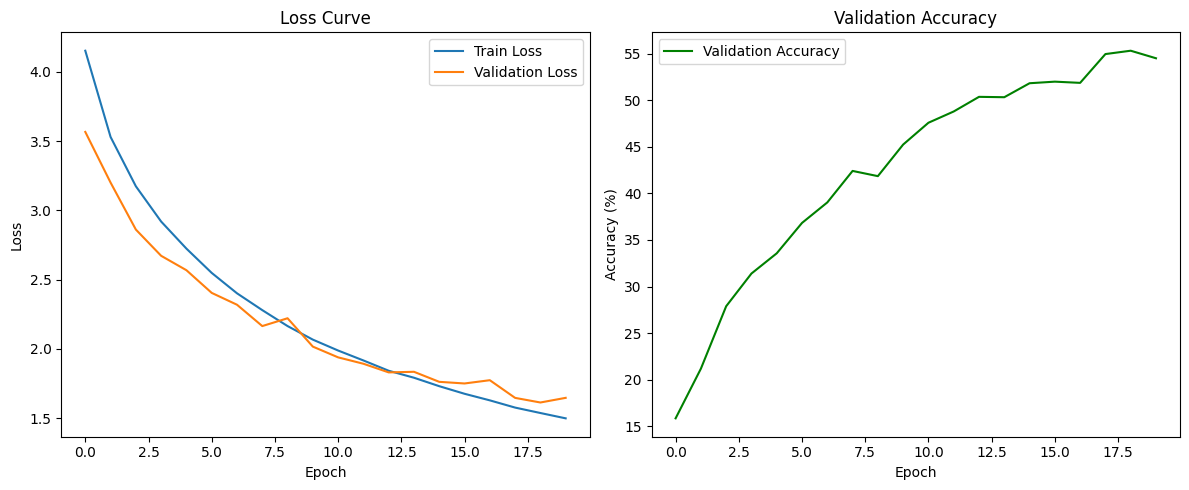


Running: LeakyReLU, SGD, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 4.0483 - Val Loss: 3.5749 - Val Acc: 14.18%
Epoch [2/20] - Train Loss: 3.3157 - Val Loss: 3.1085 - Val Acc: 22.10%
Epoch [3/20] - Train Loss: 2.8763 - Val Loss: 2.6258 - Val Acc: 30.81%
Epoch [4/20] - Train Loss: 2.5604 - Val Loss: 2.4193 - Val Acc: 36.01%
Epoch [5/20] - Train Loss: 2.3104 - Val Loss: 2.2482 - Val Acc: 40.42%
Epoch [6/20] - Train Loss: 2.1096 - Val Loss: 2.0453 - Val Acc: 44.51%
Epoch [7/20] - Train Loss: 1.9526 - Val Loss: 1.9360 - Val Acc: 47.01%
Epoch [8/20] - Train Loss: 1.8165 - Val Loss: 1.7887 - Val Acc: 50.91%
Epoch [9/20] - Train Loss: 1.7103 - Val Loss: 1.7516 - Val Acc: 51.76%
Epoch [10/20] - Train Loss: 1.6200 - Val Loss: 1.6529 - Val Acc: 54.08%
Epoch [11/20] - Train Loss: 1.5237 - Val Loss: 1.5924 - Val Acc: 55.64%
Epoch [12/20] - Train Loss: 1.4561 - Val Loss: 1.5772 - Val Acc: 56.31%
Epoch [13/20] - Train Loss: 1.3865 - Val Loss: 1.5434 - Val Acc: 56.71%
Epoch [14/20] - Train Loss

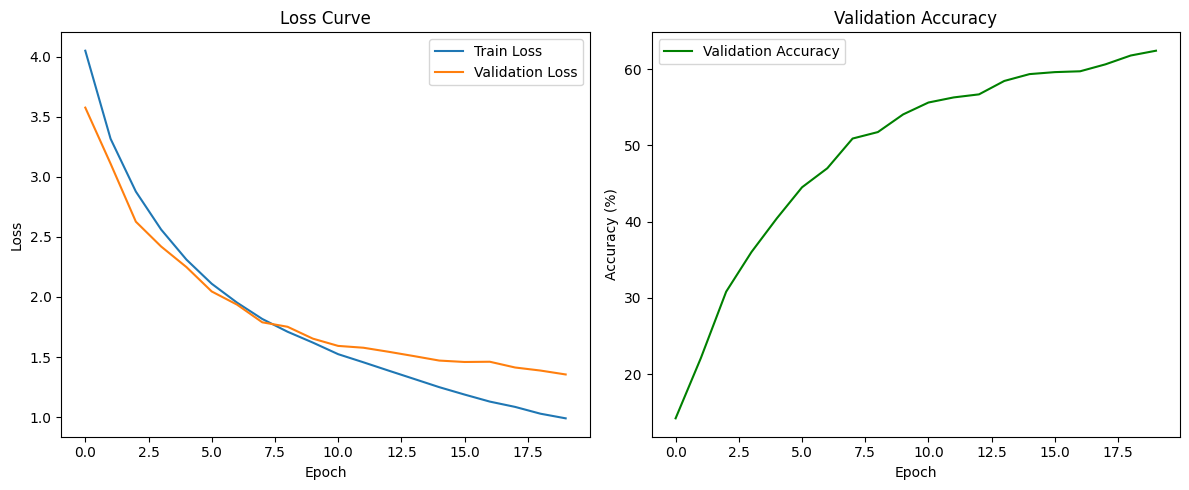

NameError: name 'pd' is not defined

In [5]:
results = run_experiments(
    dataset_name='CIFAR100',
    activation_list=[nn.ReLU, nn.LeakyReLU],
    optimizer_list=['Adam', 'SGD'],
    dropout_rates=[0.3, 0.5],
    learning_rates=[0.001, 0.01],
    num_epochs=20
)
